## Satellite-Based Paddy Crop Health Prediction

In [38]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from xgboost import XGBClassifier

### Data Analysis (EDA) & Model Training

In [7]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\Data_crop\paddy_dataset.csv")
df.head()

,EVI,NDVI,NDWI,rainfall,temp,label
0,2.172272,0.283475,-0.250982,1581.458054,24.071654,1
1,2.372676,0.270133,-0.236005,1581.458054,24.071654,1
2,2.649612,0.271282,-0.230421,1581.458054,24.071654,1
3,2.287467,0.248571,-0.215014,1581.458054,24.071654,0
4,1.799636,0.230626,-0.205580,1581.458054,24.071654,0


#### info

In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EVI       1280 non-null   float64
 1   NDVI      1280 non-null   float64
 2   NDWI      1280 non-null   float64
 3   rainfall  1280 non-null   float64
 4   temp      1280 non-null   float64
 5   label     1280 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 60.1 KB
None


#### describe

In [18]:
print(df.describe())

               EVI         NDVI         NDWI     rainfall         temp  \
count  1280.000000  1280.000000  1280.000000  1280.000000  1280.000000   
mean      4.631225     0.407310    -0.356835  1594.764899    24.749591   
std     112.918369     0.125762     0.115965    13.312046     0.678202   
min    -527.500000     0.066966    -0.524990  1581.458054    24.071654   
25%       1.579770     0.280111    -0.450476  1581.458054    24.071654   
50%       3.094110     0.478636    -0.426289  1594.764899    24.749591   
75%       3.917808     0.509956    -0.236804  1608.071743    25.427528   
max    3935.000000     0.606182    -0.018182  1608.071743    25.427528   

             label  
count  1280.000000  
mean      1.438281  
std       0.765318  
min       0.000000  
25%       1.000000  
50%       2.000000  
75%       2.000000  
max       2.000000  


#### Standardization

In [26]:
cols = ['EVI', 'NDVI', 'NDWI', 'rainfall', 'temp']

scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])

print(df.head())

        EVI      NDVI      NDWI  rainfall  temp  label
0 -0.021785 -0.985061  0.913152      -1.0  -1.0      1
1 -0.020009 -1.091190  1.042351      -1.0  -1.0      1
2 -0.017556 -1.082057  1.090526      -1.0  -1.0      1
3 -0.020764 -1.262709  1.223437      -1.0  -1.0      0
4 -0.025086 -1.405462  1.304822      -1.0  -1.0      0


### Class Distribution

In [33]:
print(df["label"].value_counts())

label
2    778
1    285
0    217
Name: count, dtype: int64


### Correlation Analysis

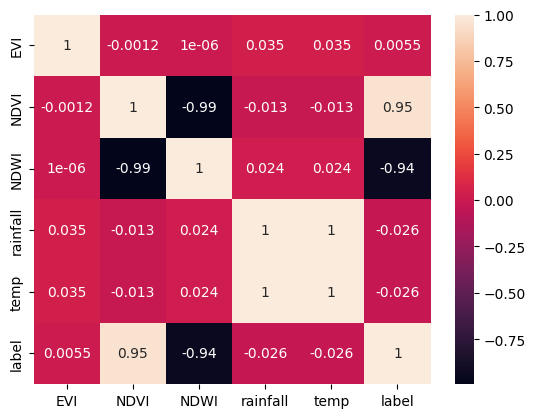

In [40]:
import seaborn as sns

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

### Boxplot

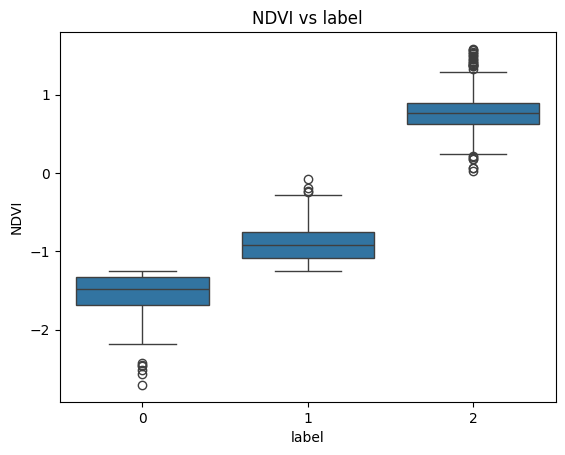

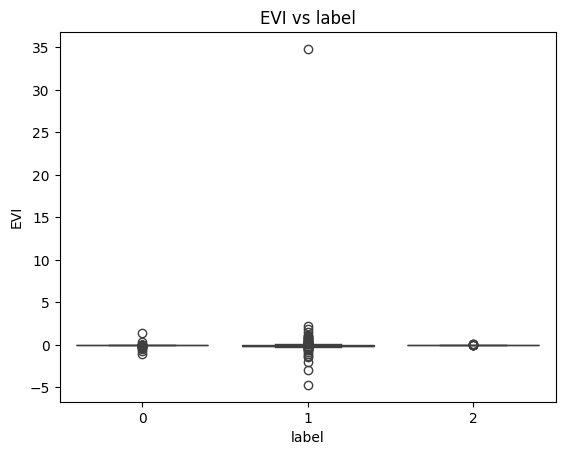

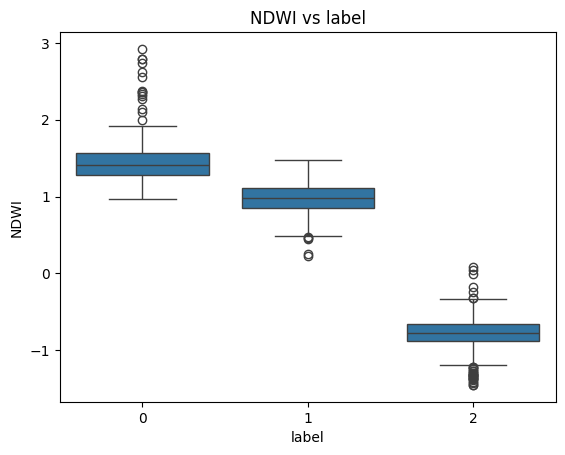

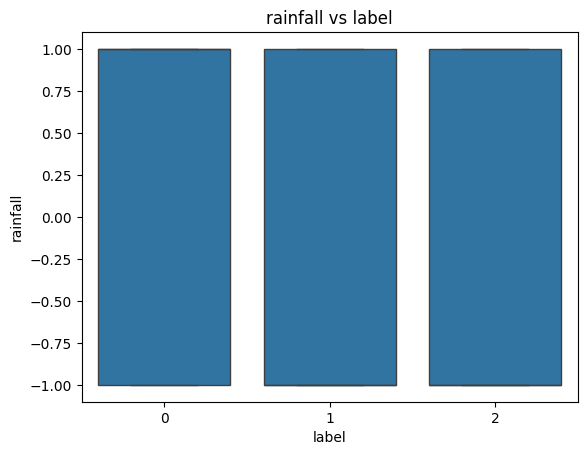

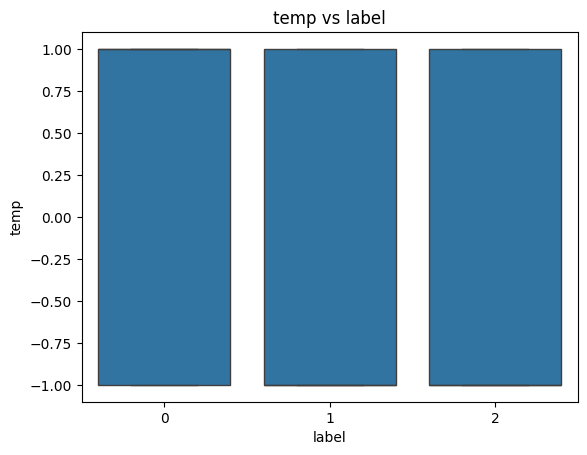

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['NDVI', 'EVI', 'NDWI', 'rainfall', 'temp']

for feature in features:
    plt.figure()
    sns.boxplot(x='label', y=feature, data=df)  # ✅ fixed
    plt.title(f"{feature} vs label")
    plt.show()

### Prepare Data 

In [48]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1 : Random Forest

In [51]:
rf_model = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)


###  Performance

In [54]:
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


### Cross validation

In [57]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print(scores)

[0.99609375 1.         1.         0.99609375 1.        ]


### Train & Test Accuracy

In [60]:
from sklearn.metrics import accuracy_score

# Train accuracy
rf_train_pred = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)

# Test accuracy
rf_test_pred = rf_model.predict(X_test)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print("RF Train Accuracy:", rf_train_acc)
print("RF Test Accuracy:", rf_test_acc)

RF Train Accuracy: 1.0
RF Test Accuracy: 1.0


#### Feature Importance

This tells:

Which feature the model is using the most

In [63]:
importance = rf_model.feature_importances_

features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(imp_df)

    Feature  Importance
1      NDVI    0.542558
2      NDWI    0.320833
0       EVI    0.135753
3  rainfall    0.000464
4      temp    0.000393


#### Visualize one tree

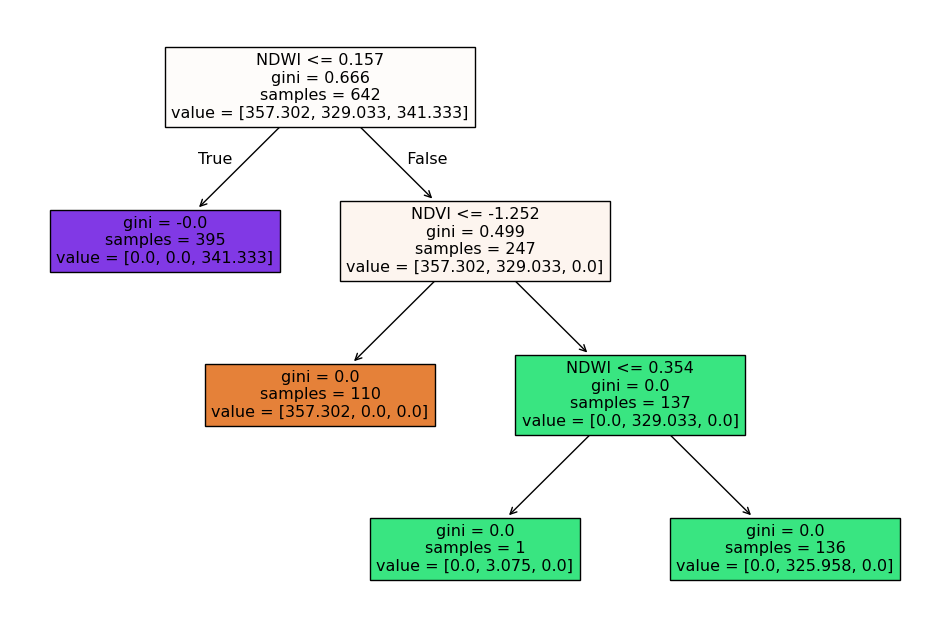

In [66]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(rf_model.estimators_[0], feature_names=X.columns, filled=True)
plt.show()

In [68]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_pred))

[[ 46   0   0]
 [  0  63   0]
 [  0   0 147]]


### Model Evaluation

In [73]:
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

print("\nClassification Report (RF):")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0

Classification Report (RF):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        63
           2       1.00      1.00      1.00       147

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



In [78]:
df

,EVI,NDVI,NDWI,rainfall,temp,label
0,-0.021785,-0.985061,0.913152,-1.0,-1.0,1
1,-0.020009,-1.091190,1.042351,-1.0,-1.0,1
2,-0.017556,-1.082057,1.090526,-1.0,-1.0,1
3,-0.020764,-1.262709,1.223437,-1.0,-1.0,0
4,-0.025086,-1.405462,1.304822,-1.0,-1.0,0
...,...,...,...,...,...,...
1275,-0.011523,0.636949,-0.659211,1.0,1.0,2
1276,-0.011345,0.454076,-0.496613,1.0,1.0,2
1277,-0.006278,0.287659,-0.338899,1.0,1.0,2
1278,-0.009271,0.413840,-0.445272,1.0,1.0,2


### Give new input to model

In [84]:
# Example new data
new_data = [[-0.011523,	0.636949,	-0.659211,	1.0	,1.0	]]  

prediction = rf_model.predict(new_data)

print("Predicted Label:", prediction)

Predicted Label: [2]


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Model 2: Support Vector Machine (SVM)

It is used to separate different groups (classes)


In [87]:
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.96875


### Visualization

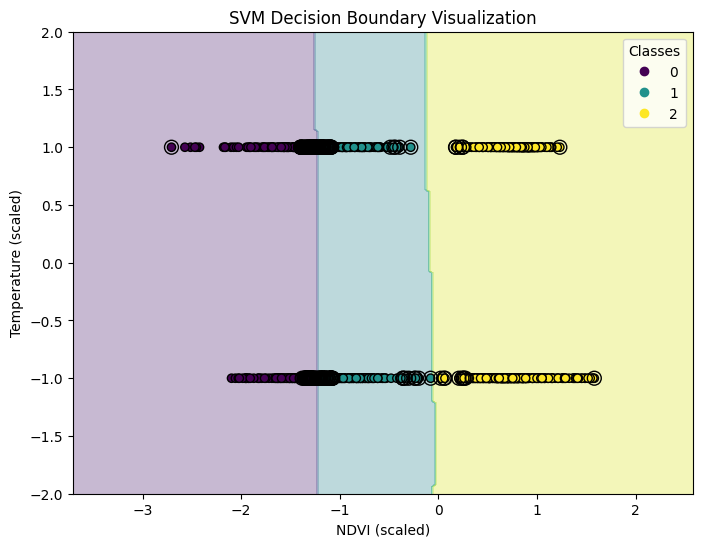

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder

#  1. Select only 2 features for visualization
X_vis = df[["NDVI", "temp"]]
y_vis = df["label"]

#  2. Encode labels (IMPORTANT)
le = LabelEncoder()
y_encoded = le.fit_transform(y_vis)

#  3. Scale features (VERY IMPORTANT for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

#  4. Train SVM model
model = SVC(kernel='rbf')
model.fit(X_scaled, y_encoded)

#  5. Create mesh grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

#  6. Predict for grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#  7. Plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

#  8. Plot actual data points
scatter = plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_encoded,
    edgecolors='k'
)

#  9. Plot support vectors (VERY IMPORTANT )
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=100,
    facecolors='none',
    edgecolors='black',
    label="Support Vectors"
)

#  10. Labels & title
plt.xlabel("NDVI (scaled)")
plt.ylabel("Temperature (scaled)")
plt.title("SVM Decision Boundary Visualization")

#  11. Legend (convert numbers back to labels)
handles, _ = scatter.legend_elements()
labels = le.classes_
plt.legend(handles, labels, title="Classes")

plt.show()

### Model Evaluation

In [97]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)

# Classification Report
print("\nClassification Report (SVM):")
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.96875

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.95      0.87      0.91        46
           1       0.91      0.97      0.94        63
           2       1.00      1.00      1.00       147

    accuracy                           0.97       256
   macro avg       0.95      0.95      0.95       256
weighted avg       0.97      0.97      0.97       256



In [99]:
# Confusion Matrix
print("\nConfusion Matrix (SVM):")
print(confusion_matrix(y_test, svm_pred))


Confusion Matrix (SVM):
[[ 40   6   0]
 [  2  61   0]
 [  0   0 147]]


### Prediction

In [102]:
# Example new data
new_data = [[-0.011523,	0.636949,	-0.659211,	1.0	,1.0	]]   


prediction = svm_model.predict(new_data)

print("Predicted Label:", prediction)

Predicted Label: [2]


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


## Model 3: XGBoost

In [107]:
# Model
xgb_model = XGBClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    reg_alpha=1,
    reg_lambda=1
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, xgb_pred))

Accuracy: 1.0


### Model Evaluation

In [111]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", xgb_acc)

# Classification Report
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, xgb_pred))


XGBoost Accuracy: 1.0

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        63
           2       1.00      1.00      1.00       147

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



In [113]:
# Confusion Matrix (optional)
print("\nConfusion Matrix (XGBoost):")
print(confusion_matrix(y_test, xgb_pred))


Confusion Matrix (XGBoost):
[[ 46   0   0]
 [  0  63   0]
 [  0   0 147]]


### Cross-validation

In [116]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X, y, cv=5)
print(scores)

[0.99609375 1.         1.         0.99609375 0.99609375]


### Prediction

In [119]:
# Example new data
new_data = [[-0.011523,	0.636949,	-0.659211,	1.0	,1.0  ]]  


prediction = xgb_model.predict(new_data)

print("Predicted Label:", prediction)

Predicted Label: [2]
